FIRST FIVE ROWS
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


SUMMARY STATISTICS
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.9

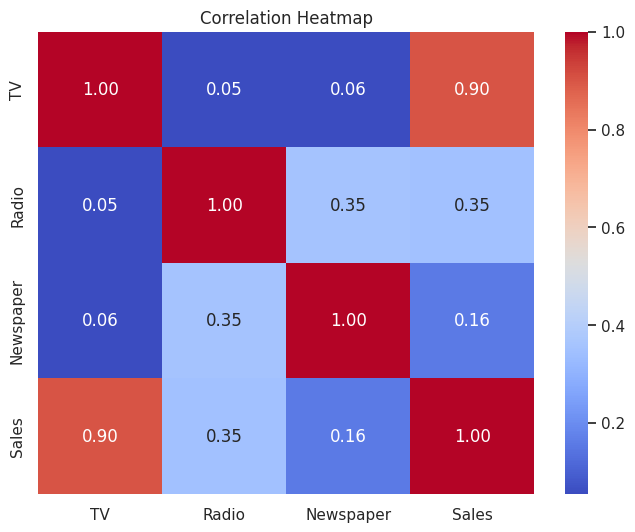

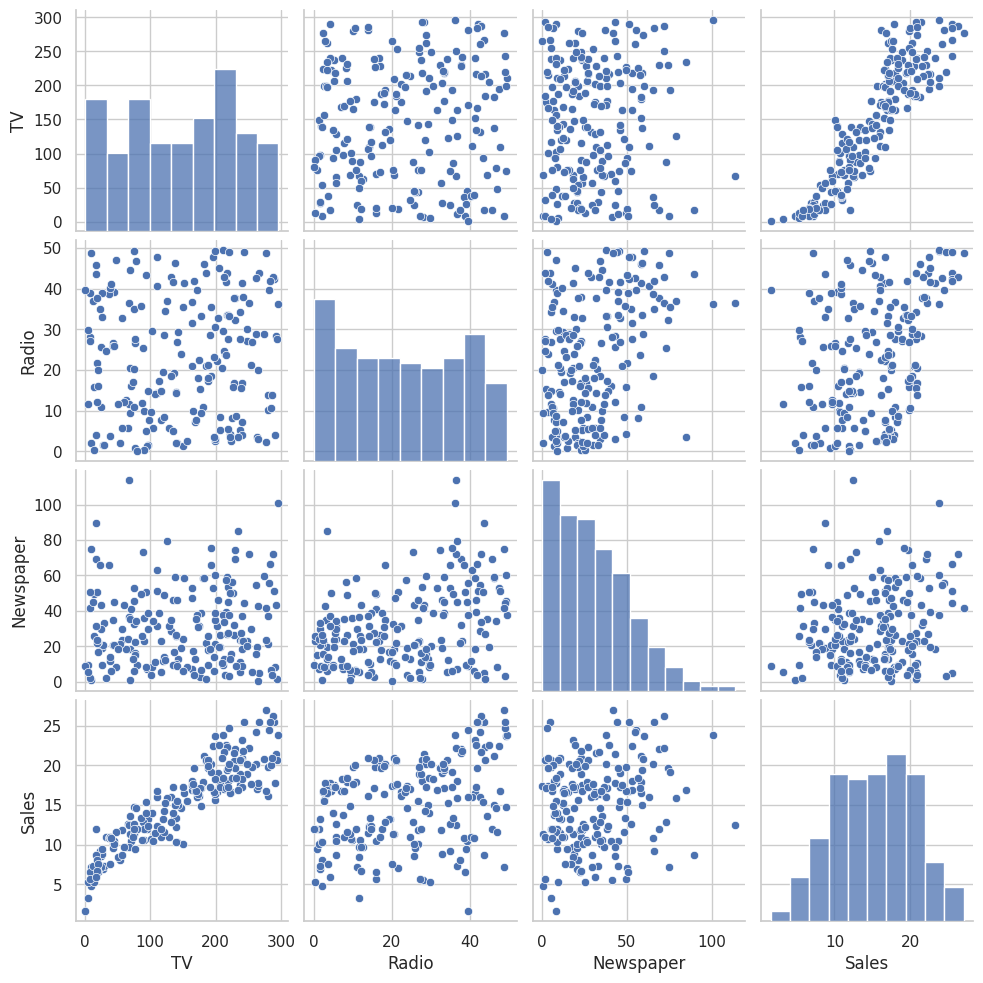

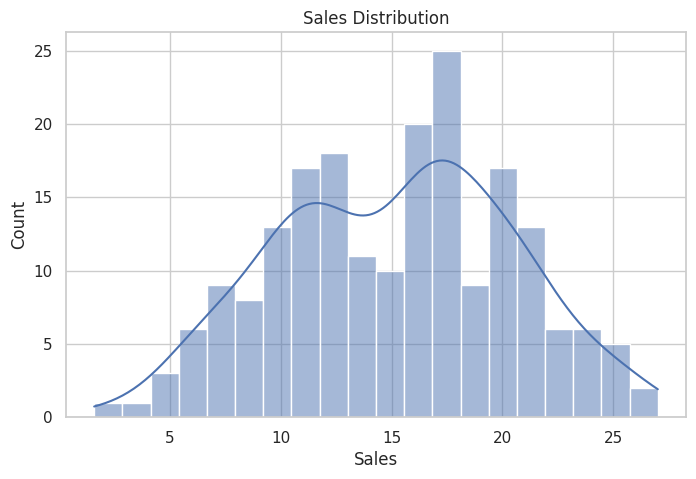

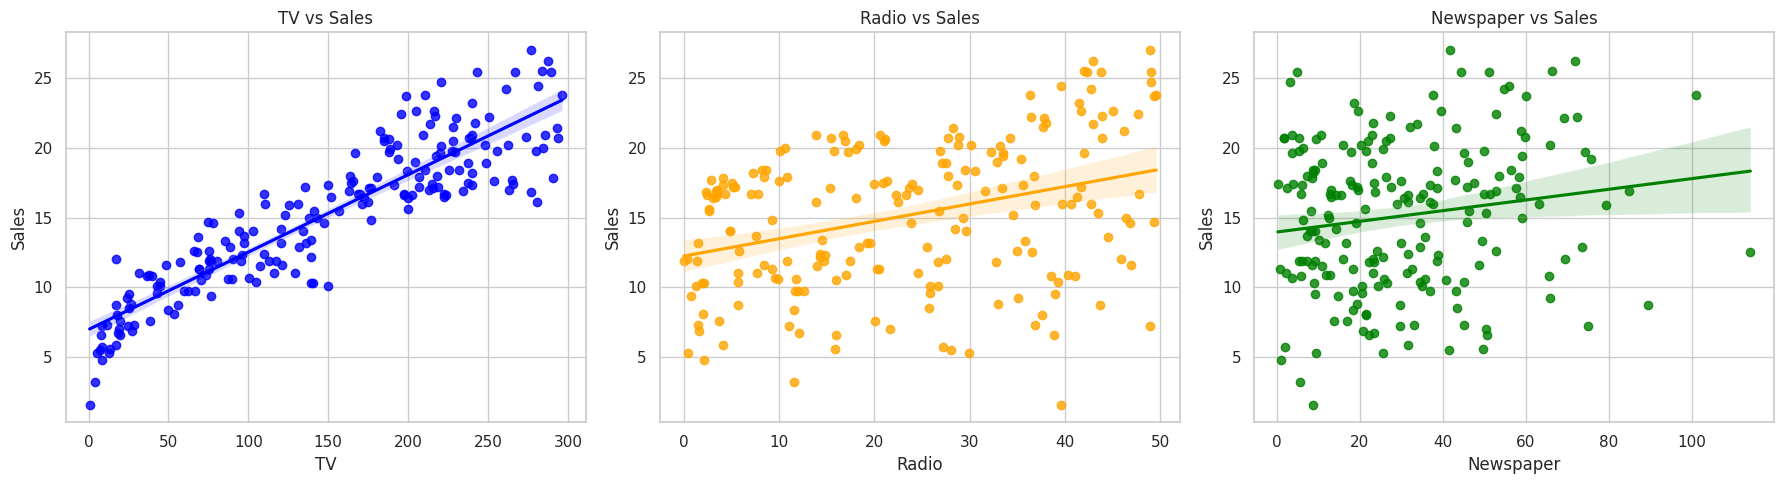



CROSS VALIDATION
Scores: [0.87556263 0.93177791 0.92150403 0.84554586 0.90247132]
Average R²: 0.8953723525274103


MODEL PERFORMANCE
R² Score : 0.9059
MAE      : 1.2748
RMSE     : 1.7052


MODEL COEFFICIENTS
Intercept : 4.7141
TV           : 0.0545
Radio        : 0.1009
Newspaper    : 0.0043


FEATURE IMPORTANCE
     Feature  Coefficient
1      Radio     0.100945
0         TV     0.054509
2  Newspaper     0.004337


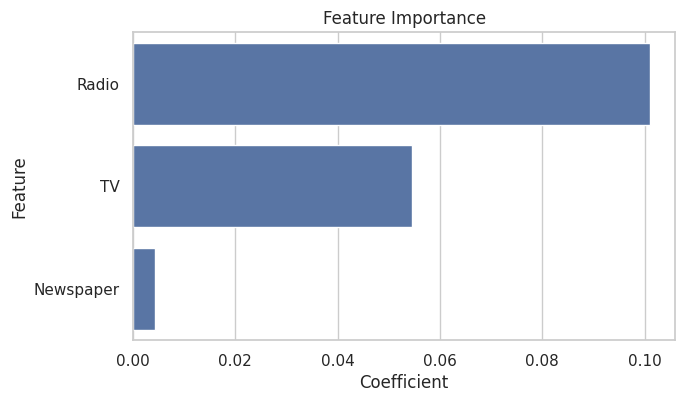

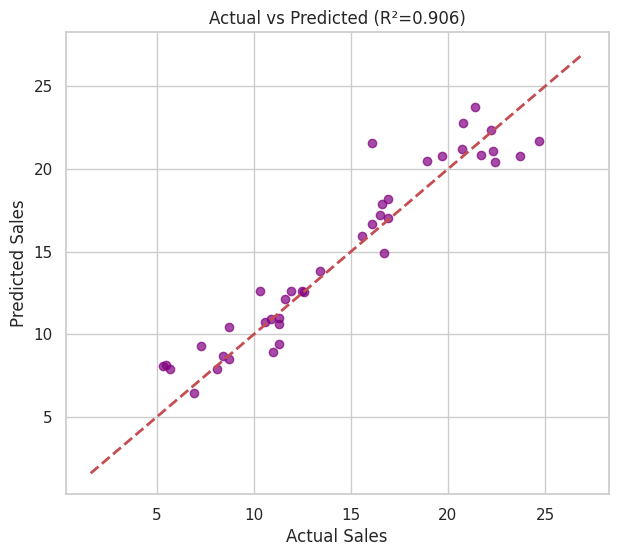

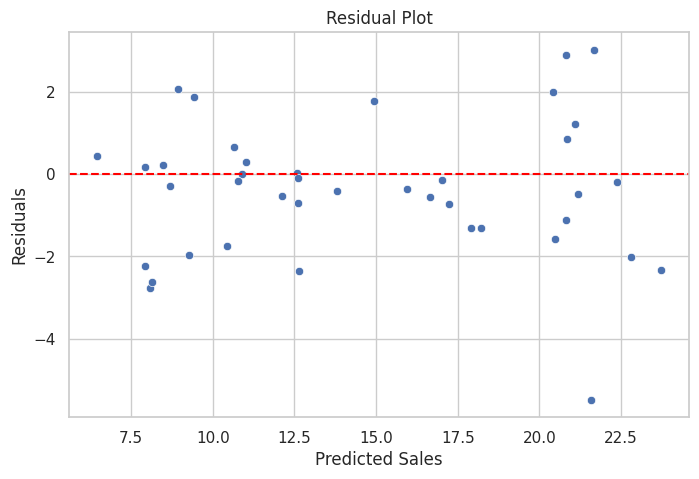

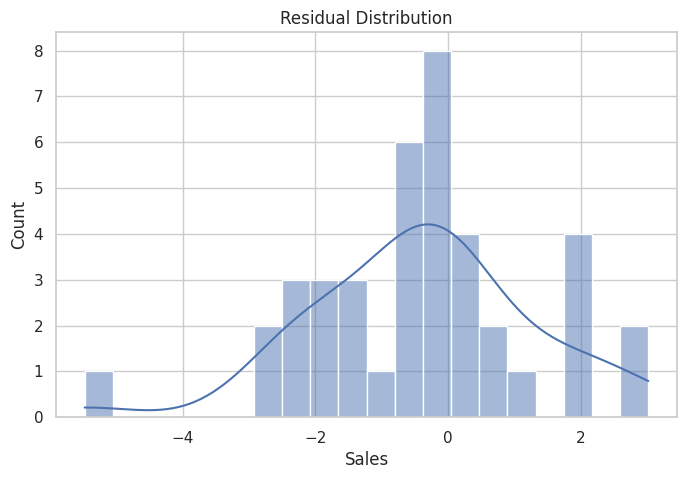


Predictions saved as predictions.csv
Feature importance saved as feature_importance.csv
Model saved as advertising_model.pkl


NEW DATA PREDICTION
Advertising Budget
    TV  Radio  Newspaper
0  250     35         40

Predicted Sales : 22.05


PROJECT COMPLETED SUCCESSFULLY
Generated Files:
1. predictions.csv
2. feature_importance.csv
3. advertising_model.pkl


In [1]:
# ==============================================================================
# ADVERTISING SALES PREDICTION PROJECT
# Complete Machine Learning Pipeline
# ==============================================================================

# ==========================
# Import Libraries
# ==========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ==========================
# Plot Settings
# ==========================
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("advertising.csv")

print("="*70)
print("FIRST FIVE ROWS")
print("="*70)
print(df.head())

print("\n")
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(df.info())

print("\n")
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(df.describe())

print("\nDataset Shape:", df.shape)

# ==========================
# Missing Values
# ==========================
print("\n")
print("="*70)
print("MISSING VALUES")
print("="*70)
print(df.isnull().sum())

# ==========================
# Duplicate Values
# ==========================
print("\nDuplicate Rows:", df.duplicated().sum())

# ==============================================================================
# Exploratory Data Analysis (EDA)
# ==============================================================================

# ----------------------------
# Correlation Heatmap
# ----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ----------------------------
# Pairplot
# ----------------------------
sns.pairplot(df)
plt.show()

# ----------------------------
# Distribution of Sales
# ----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=20, kde=True)
plt.title("Sales Distribution")
plt.show()

# ----------------------------
# Regression Plots
# ----------------------------
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.regplot(x="TV", y="Sales", data=df, ax=axes[0], color="blue")
axes[0].set_title("TV vs Sales")

sns.regplot(x="Radio", y="Sales", data=df, ax=axes[1], color="orange")
axes[1].set_title("Radio vs Sales")

sns.regplot(x="Newspaper", y="Sales", data=df, ax=axes[2], color="green")
axes[2].set_title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

# ==============================================================================
# Feature Selection
# ==============================================================================
X = df[["TV","Radio","Newspaper"]]
y = df["Sales"]

# ==============================================================================
# Train Test Split
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==============================================================================
# Model Training
# ==============================================================================
model = LinearRegression()

model.fit(X_train, y_train)

# ==============================================================================
# Cross Validation
# ==============================================================================
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\n")
print("="*70)
print("CROSS VALIDATION")
print("="*70)
print("Scores:", scores)
print("Average R²:", scores.mean())

# ==============================================================================
# Prediction
# ==============================================================================
y_pred = model.predict(X_test)

# ==============================================================================
# Evaluation
# ==============================================================================
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("\n")
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# ==============================================================================
# Coefficients
# ==============================================================================
print("\n")
print("="*70)
print("MODEL COEFFICIENTS")
print("="*70)

print(f"Intercept : {model.intercept_:.4f}")

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:12} : {coef:.4f}")

# ==============================================================================
# Feature Importance
# ==============================================================================
importance = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\n")
print("="*70)
print("FEATURE IMPORTANCE")
print("="*70)

print(importance)

plt.figure(figsize=(7,4))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

# ==============================================================================
# Actual vs Predicted
# ==============================================================================
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    color="purple",
    alpha=0.7
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted (R²={r2:.3f})")

plt.show()

# ==============================================================================
# Residual Plot
# ==============================================================================
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# ==============================================================================
# Residual Distribution
# ==============================================================================
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# ==============================================================================
# Save Predictions
# ==============================================================================
predictions = pd.DataFrame({
    "Actual Sales":y_test,
    "Predicted Sales":y_pred
})

predictions.to_csv(
    "predictions.csv",
    index=False
)

print("\nPredictions saved as predictions.csv")

# ==============================================================================
# Save Feature Importance
# ==============================================================================
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved as feature_importance.csv")

# ==============================================================================
# Save Model
# ==============================================================================
joblib.dump(
    model,
    "advertising_model.pkl"
)

print("Model saved as advertising_model.pkl")

# ==============================================================================
# Predict New Customer
# ==============================================================================
print("\n")
print("="*70)
print("NEW DATA PREDICTION")
print("="*70)

new_customer = pd.DataFrame({
    "TV":[250],
    "Radio":[35],
    "Newspaper":[40]
})

new_prediction = model.predict(new_customer)

print("Advertising Budget")
print(new_customer)

print(f"\nPredicted Sales : {new_prediction[0]:.2f}")

# ==============================================================================
# Project Completed
# ==============================================================================
print("\n")
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)
print("Generated Files:")
print("1. predictions.csv")
print("2. feature_importance.csv")
print("3. advertising_model.pkl")